In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')

['.config', 'heart.csv', 'sample_data']


**Importing and understanding our dataset**

In [2]:
dataset = pd.read_csv("heart.csv")

Verifying it as a 'dataframe' object in pandas

In [3]:
type(dataset)

pandas.core.frame.DataFrame

Shape of dataset

In [4]:
dataset.shape

(303, 14)

###Printing out a few columns

In [5]:
dataset.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [6]:
dataset.sample(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
113,43,1,0,110,211,0,1,161,0,0.0,2,0,3,1
284,61,1,0,140,207,0,0,138,1,1.9,2,1,3,0
138,57,1,0,110,201,0,1,126,1,1.5,1,0,1,1
80,41,1,2,112,250,0,1,179,0,0.0,2,0,2,1
252,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
191,58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
22,42,1,0,140,226,0,1,178,0,0.0,2,0,2,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
182,61,0,0,130,330,0,0,169,0,0.0,2,0,2,0


Description

In [7]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


###Analysing the 'target' variable

In [9]:
dataset["target"].describe()

,target
count,303.000000
mean,0.544554
std,0.498835
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [10]:
dataset["target"].unique()

array([1, 0])

###Checking correlation between columns

In [11]:
print(dataset.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


**Exploratory Data Analysis (EDA)**

First, analysing the target variable:

target
1    165
0    138
Name: count, dtype: int64


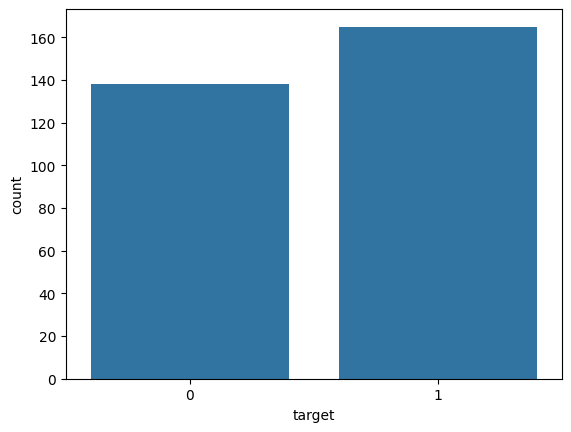

In [12]:
y = dataset["target"]

sns.countplot(x=dataset["target"])


target_temp = dataset.target.value_counts()

print(target_temp)

In [13]:
print("Percentage of patient without heart diseases: "+str(round(target_temp[0]*100/303,2)))
print("Percentage of patient with heart diseases: "+str(round(target_temp[1]*100/303,2)))

Percentage of patient without heart diseases: 45.54
Percentage of patient with heart diseases: 54.46


**Analysing the 'Sex' feature**

In [14]:
dataset["sex"].unique()

array([1, 0])

<Axes: xlabel='sex', ylabel='target'>

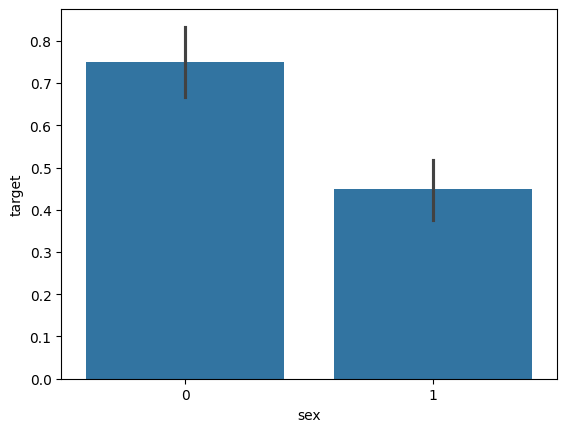

In [15]:
sns.barplot(x=dataset["sex"], y=dataset["target"])

We notice, that females are more likely to have heart problems than males

###Analysing the 'Chest Pain Type' feature

In [16]:
dataset["cp"].unique()

array([3, 2, 1, 0])

<Axes: xlabel='cp', ylabel='target'>

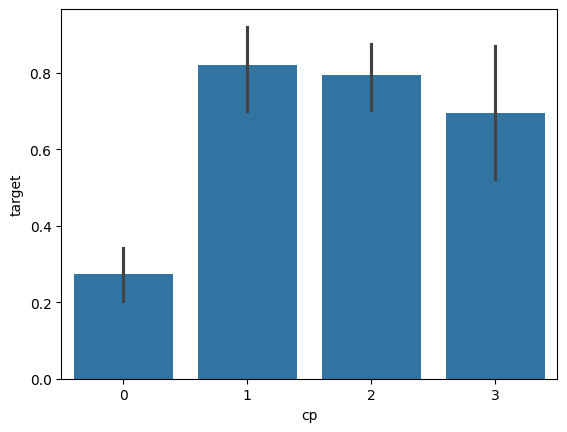

In [17]:
sns.barplot(x=dataset["cp"],y=dataset["target"])

We notice, that chest pain of '0', i.e. the ones with typical angina are much less likely to have heart problems

###Analysing the FBS feature

In [18]:
dataset["fbs"].describe()

,fbs
count,303.000000
mean,0.148515
std,0.356198
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [19]:
dataset["fbs"].unique()

array([1, 0])

<Axes: xlabel='fbs', ylabel='target'>

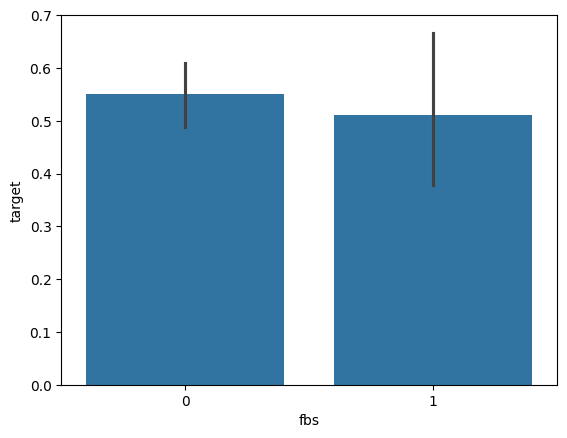

In [20]:
sns.barplot(x=dataset["fbs"],y=dataset["target"])

###Analysing the restecg feature

In [21]:
dataset["restecg"].unique()

array([0, 1, 2])

<Axes: xlabel='restecg', ylabel='target'>

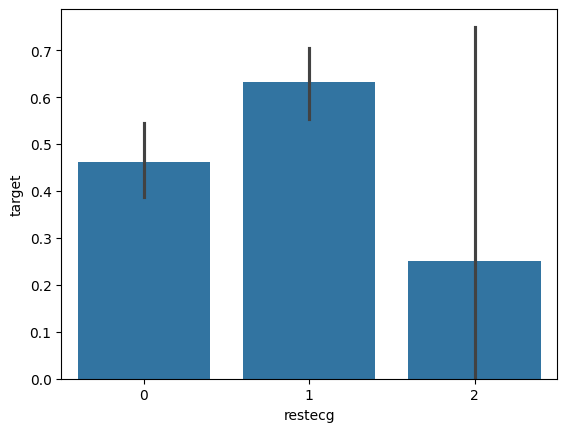

In [22]:
sns.barplot(x=dataset["restecg"],y=dataset["target"])

We realize that people with restecg '1' and '0' are much more likely to have a heart disease than with restecg '2'

###Analysing the 'exang' feature

In [23]:
dataset["exang"].unique()

array([0, 1])

<Axes: xlabel='exang', ylabel='target'>

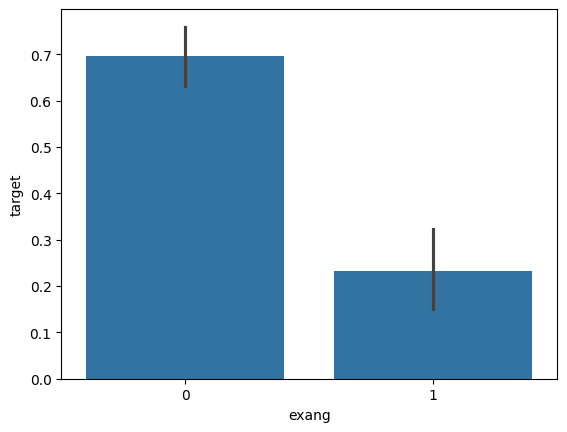

In [24]:
sns.barplot(x=dataset["exang"],y=dataset["target"])

People with exang=1 i.e. Exercise induced angina are much less likely to have heart problems

###Analysing the Slope feature

In [25]:
dataset["slope"].unique()

array([0, 2, 1])

<Axes: xlabel='slope', ylabel='target'>

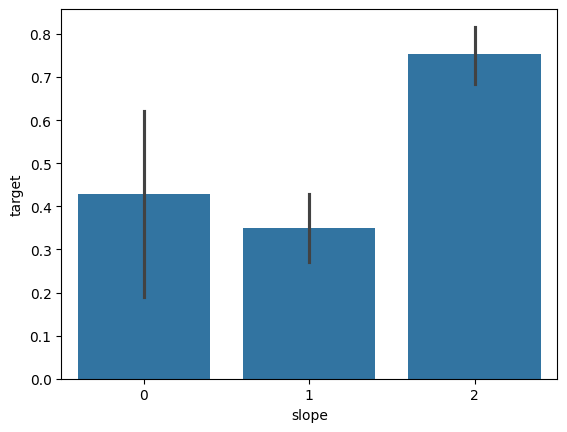

In [26]:
sns.barplot(x=dataset["slope"],y=dataset["target"])

We observe, that Slope '2' causes heart pain much more than Slope '0' and '1'

###Analysing the 'ca' feature

In [27]:
dataset["ca"].unique()

array([0, 2, 1, 3, 4])

<Axes: xlabel='ca', ylabel='count'>

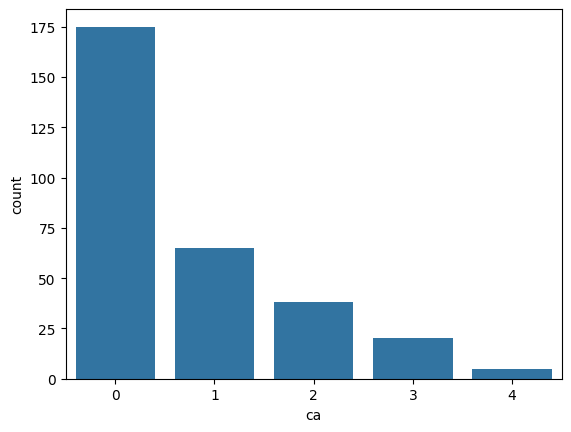

In [28]:
sns.countplot(x=dataset["ca"])

<Axes: xlabel='ca', ylabel='target'>

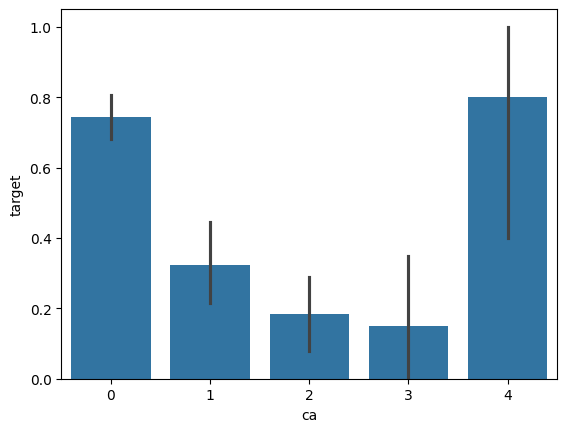

In [29]:
sns.barplot(x=dataset["ca"],y=dataset["target"])

ca=4 has astonishingly large number of heart patients

###Analysing the 'thal' feature

In [30]:
dataset["thal"].unique()

array([1, 2, 3, 0])

<Axes: xlabel='thal', ylabel='target'>

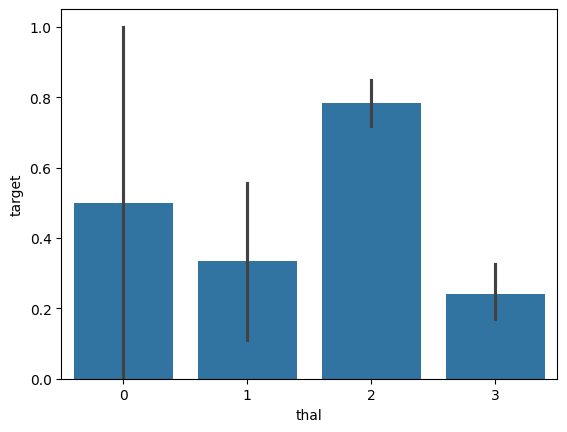

In [31]:
sns.barplot(x=dataset["thal"],y=dataset["target"])

<Axes: xlabel='thal', ylabel='Density'>

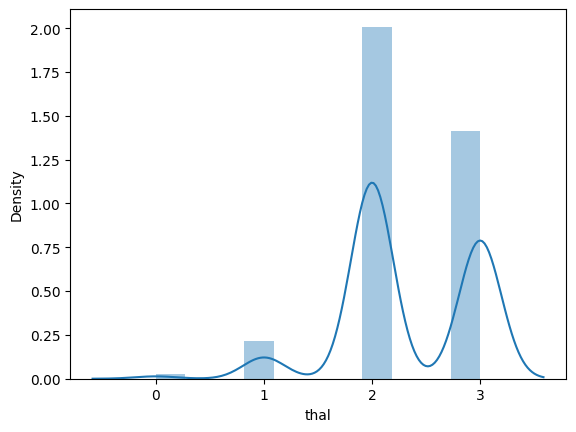

In [32]:
sns.distplot(dataset["thal"])

**Train Test Split**

In [33]:
from sklearn.model_selection import train_test_split

predictors = dataset.drop("target",axis=1)
target = dataset["target"]

X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

In [34]:
X_train.shape

(242, 13)

In [35]:
X_test.shape

(61, 13)

In [36]:
Y_train.shape

(242,)

In [37]:
Y_test.shape

(61,)

###Model Fitting

In [38]:
from sklearn.metrics import accuracy_score

###Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

In [40]:
Y_pred_lr.shape

(61,)

In [41]:
score_lr=round(accuracy_score(Y_pred_lr,Y_test)*100,2)
print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %


###Naive Bayes

In [42]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [43]:
Y_pred_nb.shape

(61,)

In [44]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 85.25 %


###K Nearest Neighbors

In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [46]:
Y_pred_knn.shape

(61,)

In [47]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 67.21 %


###Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy=0

for x in range(200):
  dt=DecisionTreeClassifier(random_state=x)
  dt.fit(X_train,Y_train)
  Y_pred_dt=dt.predict(X_test)
  current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
  if(current_accuracy>max_accuracy):
    max_accuracy = current_accuracy
    best_x = x

In [49]:
print(max_accuracy)

81.97


In [50]:
print(best_x)

11


In [51]:
dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [52]:
print(Y_pred_dt.shape)

(61,)


In [53]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 81.97 %


###SVM

In [54]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [55]:
Y_pred_svm.shape

(61,)

In [56]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 81.97 %


###Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy=0

for x in range(200):
  rf=RandomForestClassifier(random_state=x)
  rf.fit(X_train,Y_train)
  Y_pred_rf=rf.predict(X_test)
  current_accuracy=round(accuracy_score(Y_pred_rf,Y_test)*100,2)
  if(current_accuracy>max_accuracy):
    max_accuracy=current_accuracy
    best_x=x


rf=RandomForestClassifier(random_state=best_x)
rf.fit(X_train,Y_train)
Y_pred_rf=rf.predict(X_test)

In [67]:
print(max_accuracy)

88.52


In [68]:
Y_pred_rf.shape

(61,)

In [69]:
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_rf)+" %")

The accuracy score achieved using Decision Tree is: 88.52 %


#XGBoost

In [70]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

In [71]:
Y_pred_xgb.shape

(61,)

In [72]:
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)

print("The accuracy score achieved using XGBoost is: "+str(score_xgb)+" %")

The accuracy score achieved using XGBoost is: 83.61 %


###Neural Network

In [73]:
from keras.models import Sequential
from keras.layers import Dense

In [77]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=13))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [78]:
model.fit(X_train,Y_train,epochs=300)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5633 - loss: 11.5474  
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5834 - loss: 9.1701 
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5409 - loss: 10.5341 
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5699 - loss: 11.1951
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6096 - loss: 9.1763  
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6015 - loss: 10.0916 
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5767 - loss: 10.2006 
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5523 - loss: 9.7610 
Epoch 9/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5701 - loss: 9.7424  
Epoch 10/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5975 - loss: 8.6121 
Epoch 11/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5684 - loss: 8.6051 
Epoch 12/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.57

In [79]:
Y_pred_nn = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


In [80]:
Y_pred_nn.shape

(61, 1)

In [81]:
rounded = [round(x[0]) for x in Y_pred_nn]

Y_pred_nn = rounded

In [82]:
score_nn = round(accuracy_score(Y_pred_nn,Y_test)*100,2)

print("The accuracy score achieved using Neural Network is: "+str(score_nn)+" %")

The accuracy score achieved using Neural Network is: 83.61 %


###Output Final Score

In [83]:
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb,score_nn]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine",
              "K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost","Neural Network"]

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %
The accuracy score achieved using Naive Bayes is: 85.25 %
The accuracy score achieved using Support Vector Machine is: 81.97 %
The accuracy score achieved using K-Nearest Neighbors is: 67.21 %
The accuracy score achieved using Decision Tree is: 81.97 %
The accuracy score achieved using Random Forest is: 88.52 %
The accuracy score achieved using XGBoost is: 83.61 %
The accuracy score achieved using Neural Network is: 83.61 %


<Axes: xlabel='Algorithms', ylabel='Accuracy score'>

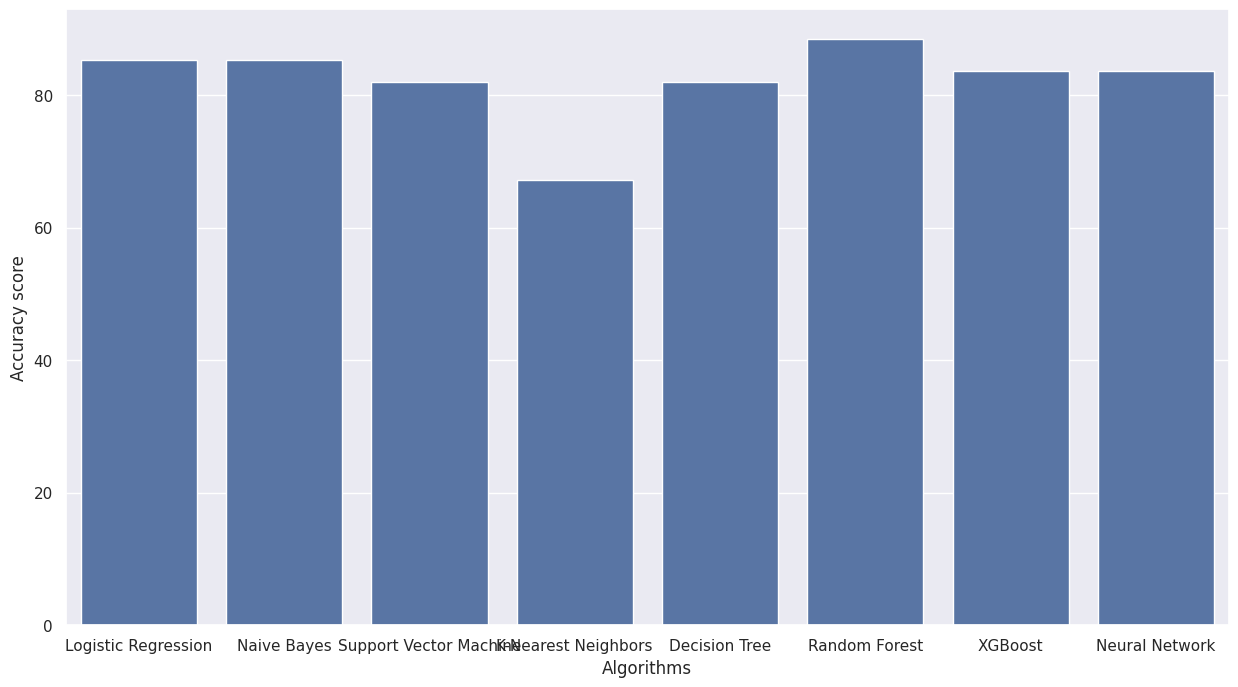

In [87]:
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

sns.barplot(x=algorithms, y=scores)